In [16]:
%pip install --no-cache-dir -q pywavelets

Note: you may need to restart the kernel to use updated packages.


In [17]:
import torch

from torchvision import datasets, transforms

from learnable_wavelets import (
    WaveletTransformParameters2D,
    WaveletTransformAnalysis2D,
    WaveletTransformSynthesis2D,
    plots as lw_plots,
    mse_loss,
    l1_sparsity_loss,
    psnr_metric,
)

import pywt
import matplotlib.pyplot as plt

In [18]:
PADDING_MODE = "reflect"
WAVELET_NAME = "db1"

PARAMS_DTYPE = torch.float32
IMAGE_DTYPE = torch.float64

In [19]:
class WaveletTransform(torch.nn.Module):
    def __init__(
        self,
        wavelet_name: str = "db4",
        padding_mode: str = "reflect",
    ):
        super().__init__()

        wavelet = pywt.Wavelet(wavelet_name)

        self.filters = torch.stack(
            [
                torch.tensor(wavelet.rec_lo),
                torch.tensor(wavelet.rec_hi),
            ]
        )
        self.params2d = WaveletTransformParameters2D()
        self.analysis = WaveletTransformAnalysis2D(padding_mode=padding_mode)
        self.synthesis = WaveletTransformSynthesis2D()

    def forward(self, x):
        filters2d = self.params2d(self.filters).to(dtype=x.dtype)

        approx, details = self.analysis(x, filters2d)

        details *= 0

        x_rec = self.synthesis(approx, details, filters2d)

        return (
            approx,
            x_rec[:, :, : x.shape[-2], : x.shape[-1]],
        )

In [20]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.ConvertImageDtype(IMAGE_DTYPE),
        transforms.Lambda(lambda x: x * 2 - 1),  # Scale to [-1, 1]
    ]
)

dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

validation_size = 3
validation_batch = torch.stack(
    [dataset[i][0] for i in range(validation_size)],
    dim=0,
)

In [21]:
model = WaveletTransform(
    wavelet_name=WAVELET_NAME,
    padding_mode=PADDING_MODE,
).to(dtype=PARAMS_DTYPE)
compiled_model = torch.compile(model, mode="max-autotune")

In [22]:
compiled_model.eval()

with torch.no_grad():
    x = validation_batch

    coeffs, x_rec = compiled_model(x)

    mse = mse_loss(x_rec, x)
    l1 = l1_sparsity_loss(coeffs)

    psnr = psnr_metric(x_rec, x)

print(f"MSE: {mse.item():.6f}")
print(f"L1 sparsity loss: {l1.item():.6f}")
print(f"PSNR: {psnr.item():.2f} dB")

MSE: 0.064016
L1 sparsity loss: 1.830954
PSNR: 63.57 dB


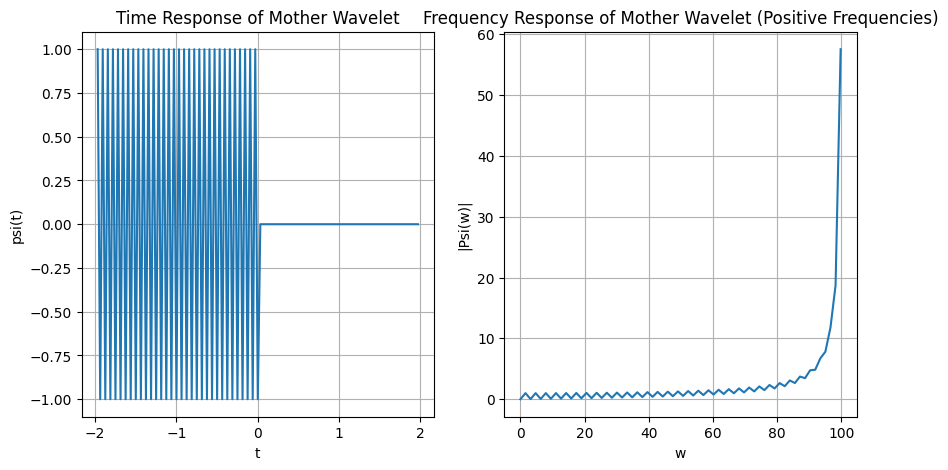

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

lw_plots.plot_wavelet(compiled_model.filters, (axs[0], axs[1]))

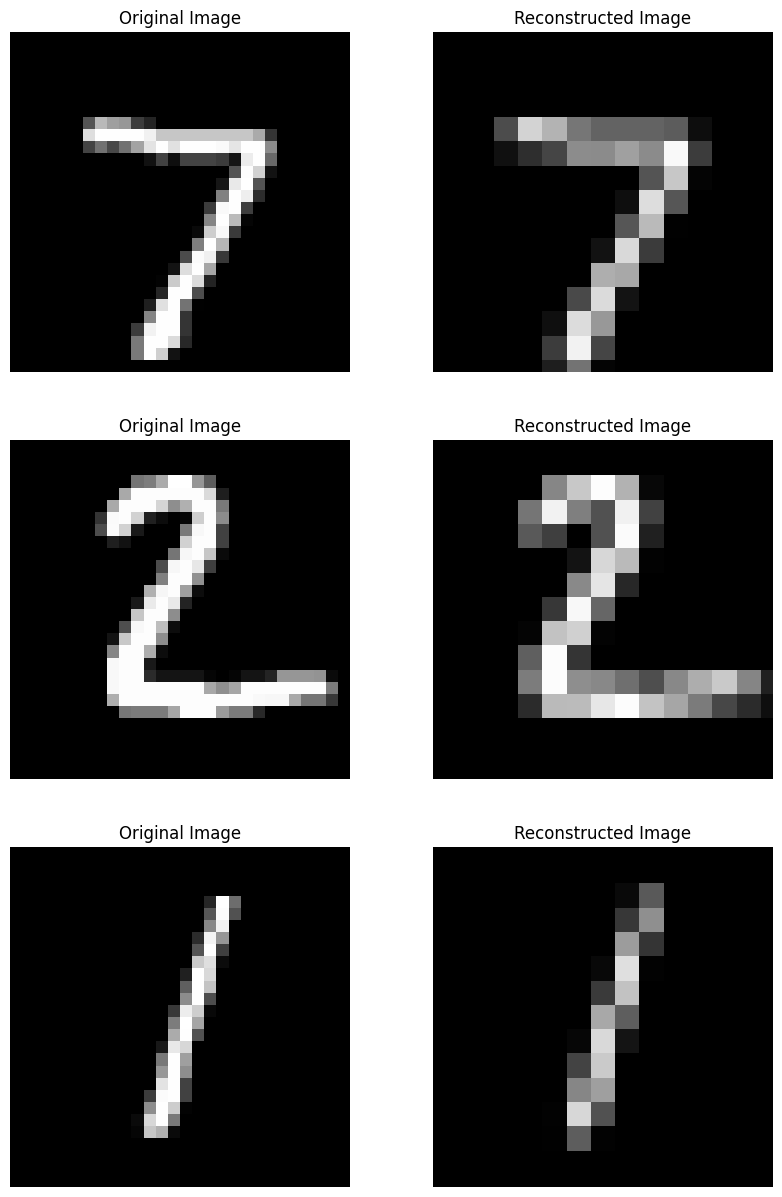

In [24]:
fig, axs = plt.subplots(validation_size, 2, figsize=(10, 5 * validation_size))

for i in range(validation_size):
    lw_plots.plot_reconstruction(
        x_rec[i : i + 1].squeeze(),
        x[i : i + 1].squeeze(),
        (axs[i, 0], axs[i, 1]),
    )